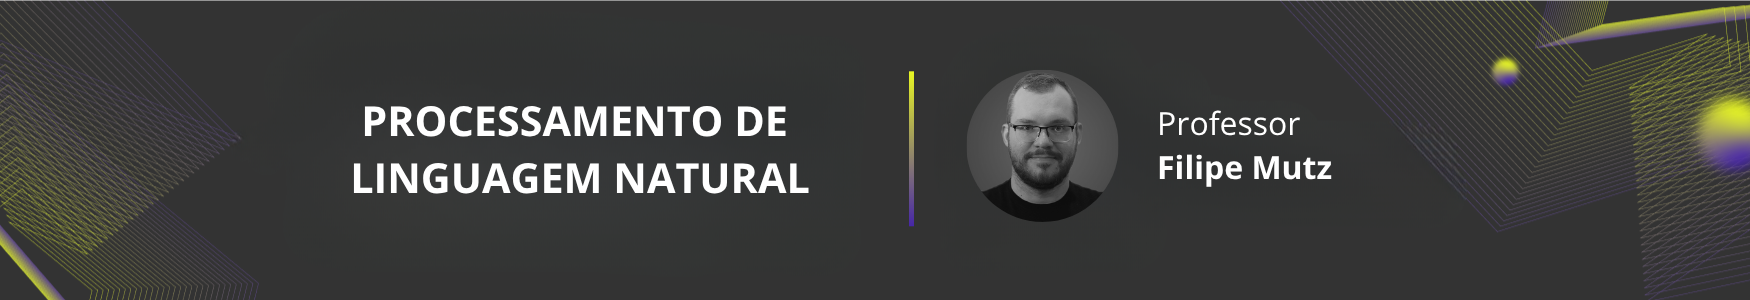

# 📝🤖 Usando LLMs Comerciais

O treinamento de LLMs de alta performance requer alta capacidade técnica, financeira, de dados e computacional. Por isto, muitas organizações optam por utilizar LLMs comerciais disponibilizados por empresas como Google, OpenAI e Amazon. A interação programática com estas LLMs é feita tipicamente via troca de mensagens com web APIs. Este notebook tem como objetivo demonstrar como realizar este tipo de interação usando como exemplo o **Google Gemini** que possui um free tier.

## Fundamentos

Como ilustrado na figura abaixo, o programa cliente envia uma requisição para a LLM que tipicamente contém uma chave de API e, dependendo do tipo de modelo, pode conter configurações de sistema, imagens, áudios, vídeos e mensagens anteriores trocadas com a LLM. Ao receber a requisição, a LLM envia como resposta um texto gerado. Alguns modelos também podem gerar informações multimodais como saída.

⚠️ **IMPORTANTE** ⚠️: Em aplicações de chat, o programa cliente deve enviar todo o histórico de mensagens trocadas a cada nova requisição.


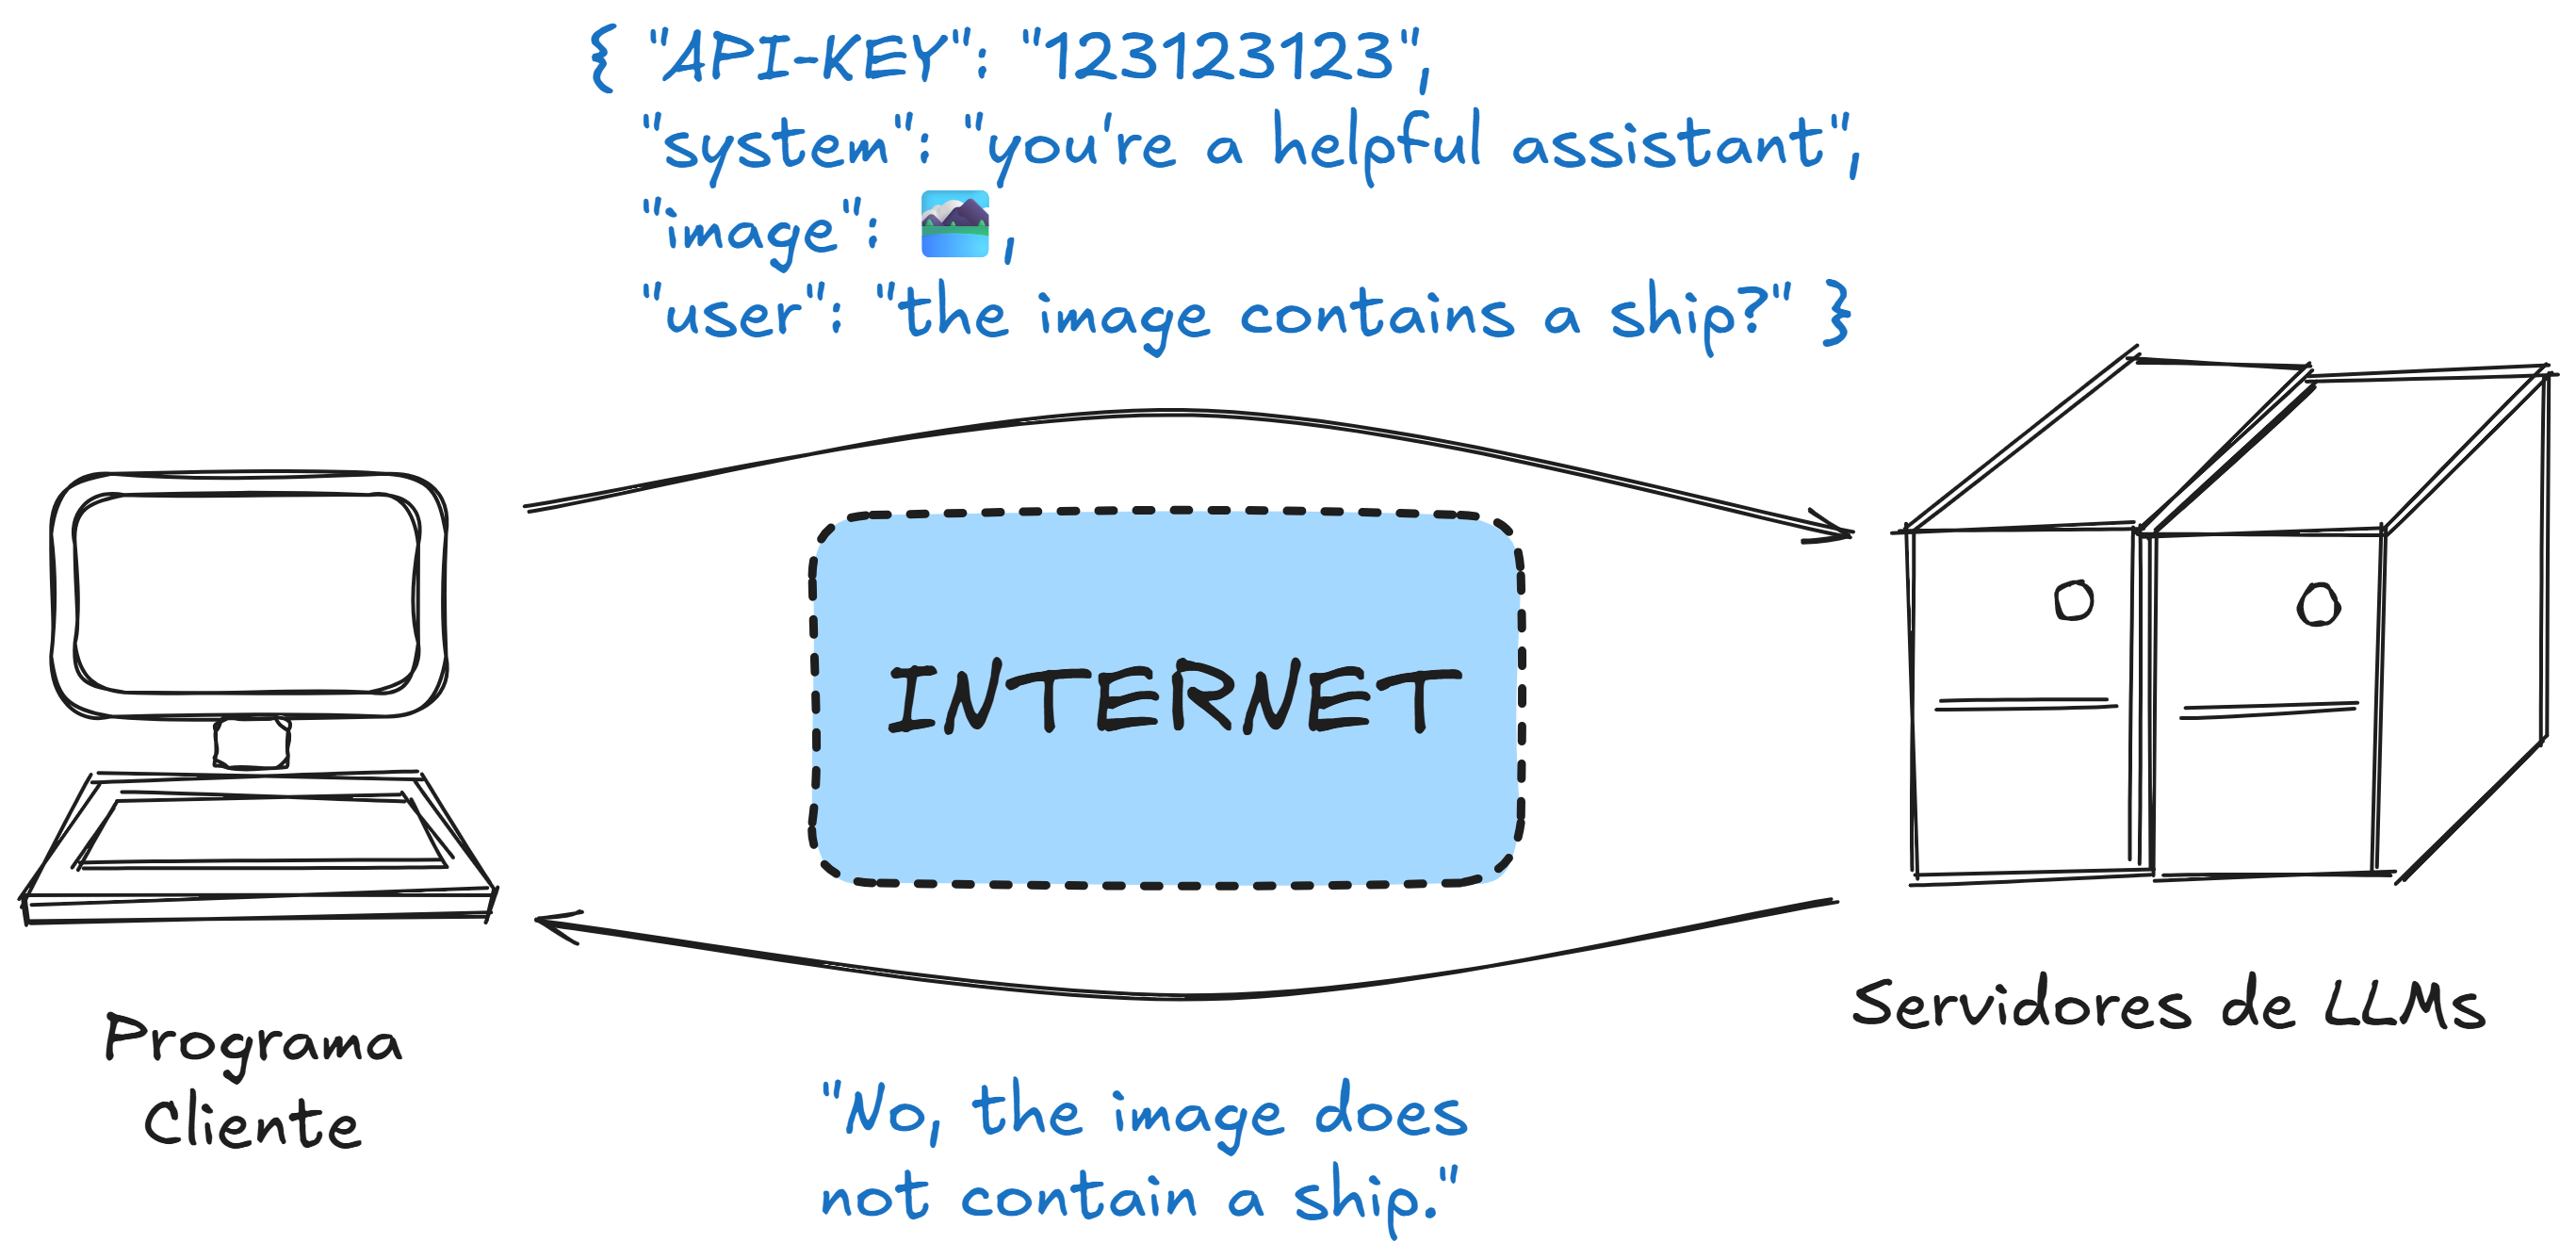

## Código

O primeiro passo para utilizar a API do Google Gemini é criar uma chave de API. [Siga as instruções indicadas neste link](https://www-merge-dev.translate.goog/blog/gemini-api-key?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc) e cole sua chave na variável indicada abaixo. [Este link leva direto à interface de aquisição de API keys](https://aistudio.google.com/app/apikey).

In [ ]:
API_KEY = "adicione sua chave aqui!"

A seguir, vamos instalar a biblioteca responsável pela interação com a LLM.

In [ ]:
!python -m pip install -U -q google-generativeai

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


### Geração Simples

Utilizar o serviço é bem simples e pode ser feito com poucas linhas. O exemplo abaixo mostra como enviar e receber strings.

In [ ]:
from IPython.display import Markdown
import google.generativeai as genai

genai.configure(api_key=API_KEY)
model = genai.GenerativeModel('gemini-1.5-flash')

response = model.generate_content('Descreva brevemente a importância de estudar inteligência artificial e ciência de dados em 2025.')
Markdown(response.text)

Em 2025, estudar inteligência artificial (IA) e ciência de dados é crucial por diversos motivos:

* **Alta demanda profissional:**  A IA e a ciência de dados impulsionam a transformação digital em todos os setores, criando uma enorme demanda por profissionais qualificados em áreas como desenvolvimento de algoritmos, análise de dados, engenharia de machine learning e ciência de dados.
* **Salários competitivos:**  Profissionais com essas habilidades recebem salários significativamente altos, refletindo a importância estratégica dessas áreas para as empresas.
* **Impacto em todas as indústrias:**  IA e ciência de dados não são mais nicho; afetam a saúde, finanças, manufatura, transporte, varejo e muito mais, oferecendo oportunidades em diversos setores.
* **Capacidade de resolução de problemas complexos:**  As ferramentas e técnicas da IA e da ciência de dados permitem resolver problemas complexos que antes eram intratáveis, gerando insights e otimizando processos.
* **Inovação e avanço tecnológico:**  O campo está em constante evolução, proporcionando oportunidades de pesquisa e desenvolvimento, contribuindo para a inovação contínua em diversas áreas.

Em suma, dominar IA e ciência de dados em 2025 significa ter acesso a oportunidades de carreira lucrativas, relevantes e impactantes, além de contribuir para a resolução de grandes desafios globais.


### Exemplo de Processamento de Textos

Considere os textos indicados abaixo, sendo os três primeiros sobre esportes e os três últimos sobre política.

In [ ]:

texts = [
    # Três textos sobre esportes
    "In the fifth game of the best-of-seven series, defending champions the Nuggets won a tense encounter 108-106. Jamal Murray scored 32 points, including the winner with just 3.6 seconds left when the scores were tied. James' 30 points and 11 assists were in vain for the Lakers. The NBA's all-time leading points scorer was chasing his fifth title and his first with the Lakers since 2020.",
    "In the Western Conference, the Oklahoma City Thunder also progressed to the last eight with a 97-89 win over the New Orleans Pelicans. Jalen Williams scored 24 points and Shai Gilgeous-Alexander added 24 with 10 rebounds to complete a 4-0 series clean sweep. The Thunder had a slender 44-43 advantage at half-time, before the Pelicans took a 80-75 lead but could not cling on as they struggled defensively.",
    "In the Eastern Conference, the Boston Celtics edged closer to the next round as they took a 3-1 advantage in their play-off series with the Miami Heat. They won the fourth match 102-88, but were dealt an injury concern as centre Kristaps Porzingis limped off the court with a calf strain shortly before half-time, and did not return. Derrick White's career-best 38 points helped the Celtics to victory, with the fifth match of the best-of-seven series taking place on Wednesday.",
    # Três textos sobre política
    "The number of people claiming asylum in Ireland has risen, with the Irish government claiming 80 percent have arrived from Northern Ireland. It has blamed the Rwanda policy - the fear of deportation - for the increase, and wants to send migrants back to the UK. Ireland's deputy leader said the 80 percent figure was not 'data-based' but is standing by the claim. British Prime Minister Rishi Sunak says 'the deterrent is... already having an impact'.BBC Verify has been looking at the rise in asylum claims in the Irish Republic and whether the Rwanda scheme is behind it.",
    "The UK government has been urged not to deploy troops on the ground in Gaza to deliver aid, with one MP calling the idea 'completely insane'. The UK is understood to be considering tasking troops with driving trucks via an American-built floating pier onto a beach in Gaza. Ex-Immigration Minister Robert Jenrick said such a move would be 'unwise' and urged the government to rule it out. Defence Minister Leo Docherty said he would not comment on speculation.The US military is building a large floating causeway off the coast of Gaza to help deliver much-needed humanitarian aid to the area.",
    "MP says he was deported from Africa over China criticism. A Conservative MP says he was deported during a trip to Djibouti because of the east African country's close ties to China. Tim Loughton, the MP for East Worthing and Shoreham, said he was detained for more than seven hours and barred from entry to Djibouti earlier this month. Mr Loughton, who was subjected to sanctions by China in 2021, described the experience as “very lonely and frightening”. China's foreign office said the accusations were baseless. Mr Loughton was in Djibouti for a 24-hour visit, which included a meeting with the British ambassador."
]


Vamos iterar sobre os textos e solicitar que a LLM classifique os textos.

In [ ]:

classes = ["fofoca de famosos", "arte", "policial", "esportes", "ciência e tecnologia", "política"]

for idx, text in enumerate(texts):
    prompt = f"""
    Considere o texto abaixo.

    {text}

    Selecione a classe que melhor descreve o texto dentre as seguintes possibilidades: {classes}.
    Responda apenas o nome da classe em minúsculo e mais nada. Não é necessário justificar a resposta.
    """

    response = model.generate_content(prompt)
    print(f"texto {idx}: {response.text}")


texto 0: esportes

texto 1: esportes

texto 2: esportes

texto 3: política

texto 4: política

texto 5: política



### Extraindo Informações mais Complexas sobre os Textos

In [ ]:
import google.generativeai as genai

genai.configure(api_key=API_KEY)
model = genai.GenerativeModel('gemini-1.5-flash')

questions = [
    "Does the text mention Lebron James?",
    "Does the text mentions the score of a match?",
    "The main point of the text is related to immigration?",
    "Does the text mention continent names?",
]

text = texts[0]

for question in questions:
    prompt = f"""
    Consider the following text:

    {text}

    {question}
    Answer only 'yes' or 'no' and nothing else.
    """

    response = model.generate_content(prompt)
    print(question, response.text)


Does the text mention Lebron James? yes
Does the text mentions the score of a match? yes
The main point of the text is related to immigration? no
Does the text mention continent names? no


### Processamento de Imagens

Considere a foto a seguir. Vamos utilizar o Gemini para extrair informações sobre a imagem.

'wget' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


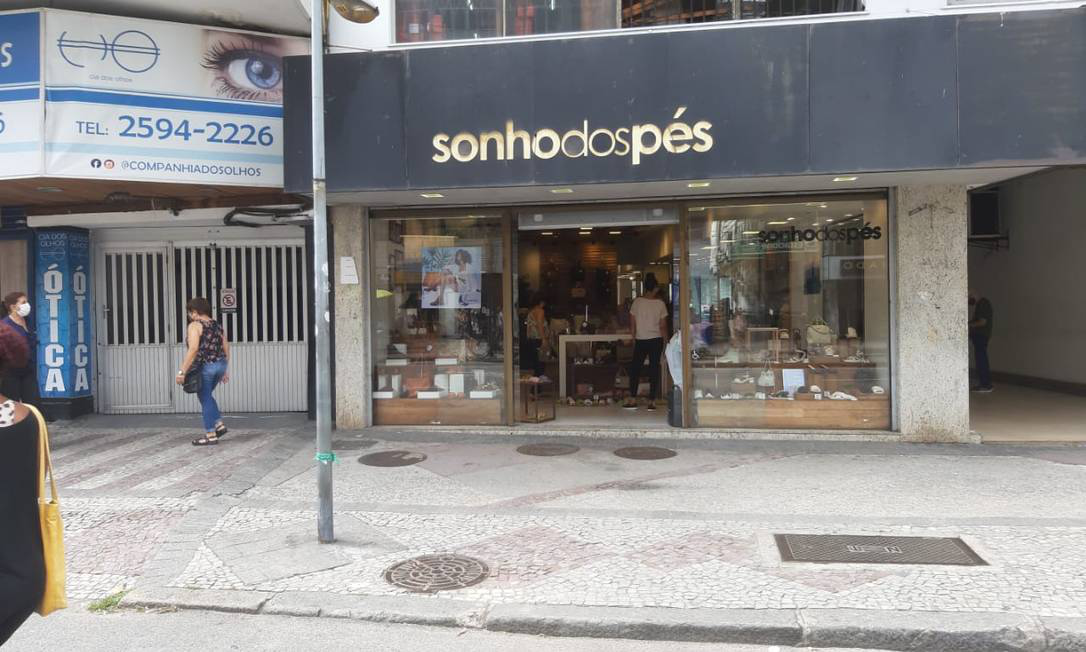

In [ ]:
import PIL
from IPython.display import Image, display

!wget -q "https://ogimg.infoglobo.com.br/rio/24921986-1fd-e40/FT1086A/comercio-de-rua-novo-horario.jpeg.jpg" -O rua.jpg

image = PIL.Image.open("rua.jpg")
display(image)

A requisição a seguir solicita informações sobre a imagem em formato estruturado.

In [ ]:

response = model.generate_content([
    image,
    """
    Consider the following image. You have three tasks:
    1) Classify the image as urban, rural, medical or textual.
    2) Identify the name of the store in the center.
    3) Identify the telephone number for the store in the left.
    Your answer should be a json in the following format:
    { 'class': 'class name', 'store name': 'name', 'telephone': 'telephone number' }
    Do not answer anything else except the json.
    """
])

print(response.text)


{ "class": "urban", "store name": "sonhodospés", "telephone": "2594-2226" }


## Geração de Código

Abaixo é feita uma requisição para o Gemini fornecer um código do design pattern criacional *Factory Method*. Neste padrão, há uma super classe que cria o objeto, mas é possível alterar o tipo do objeto em uma subclasse. Copie e cole o código gerado e verifique se compila. Após isso, observe o código conceitualmente para verificar se atende aos requisitos.

In [ ]:
from IPython.display import Markdown

response = model.generate_content("""
  How can I convert a matrix stored as a numpy array into a pandas dataframe?
  Show to assign names to rows and columns assuming that I have lists with the names.""")

Markdown(response.text)



Of course. You can convert a NumPy array into a Pandas DataFrame by passing the array directly into the `pd.DataFrame()` constructor. To assign names, you use the `index` and `columns` parameters.

Here’s a complete example demonstrating the process.

-----

### Complete Code Example

This script first creates a NumPy array and then converts it into a Pandas DataFrame, assigning custom names to the rows and columns from predefined lists.

```python
import numpy as np
import pandas as pd

# 1. Assume you have a NumPy array (e.g., a 3x4 matrix)
data_matrix = np.array([
    [10, 20, 30, 40],
    [15, 25, 35, 45],
    [18, 28, 38, 48]
])

# 2. And you have lists with the names for columns and rows
column_names = ['Temperature', 'Humidity', 'Wind Speed', 'Pressure']
row_names = ['Sensor_A', 'Sensor_B', 'Sensor_C']

# 3. Convert the array to a DataFrame, assigning the data and names
df = pd.DataFrame(data=data_matrix, index=row_names, columns=column_names)

# Print the resulting DataFrame
print(df)
```

**Output:**

```
          Temperature  Humidity  Wind Speed  Pressure
Sensor_A           10        20          30        40
Sensor_B           15        25          35        45
Sensor_C           18        28          38        48
```

-----

### Explanation of the Key Parameters

The magic happens in this single line:

`df = pd.DataFrame(data=data_matrix, index=row_names, columns=column_names)`

  * `data=data_matrix`: This is the main argument where you pass your NumPy array.
  * `index=row_names`: This parameter assigns the list of names to the DataFrame's **rows** (the index). The length of this list **must** match the number of rows in your NumPy array.
  * `columns=column_names`: This parameter assigns the list of names to the DataFrame's **columns**. The length of this list **must** match the number of columns in your NumPy array.



## Conclusão

Este notebook demonstrou como usar a API do Google Gemini para realizar diversas tarefas. Lembre-se que em aplicações reais o free tier pode ser insuficiente e será necessário avaliar os valores de planos pagos. Não deixe de colocar os conhecimentos desta aula em prática dado que eles descrevem situações que vocês provavelmente vão vivenciar no mercado de trabalho.